**What this project will do**

- Control experimental parameters
- Log experimental data
- Design clean experiment pipelines
- Implement optimization algorithms
- Build modular automation code
- Simulate lab hardware
- Think like a lab automation engineer

**Simulate an electrochemical reaction**

 where yield depends on:
- Current density
- electrolyte concentration
- Temperature
- Reaction time

**I. Simulation + Loop**
- A non-linear electrosynthesis reaction model
- An automated experiment loop
- Best-yield tracking
- Clean modular Python structure

**Step 1: Concept**
In real electrosynthesis:
- You choose parameters (current, temperature, etc.)
- Run electrolysis
- Measure yield
- Try again with new parameters

We simulate this using:
- A mathematical model
- A loop that runs multiple experiments

**Step 2: Build the Reaction Model (reaction_model.py)**



In real electrosynthesis:
- There is an optimal current
- There is an optimal temperature
- There is an optimal reaction time

Moving away from optimal conditions reduces yield.
Your function mathematically recreates that behavior.

A 4-dimensional response surface is built.
This is exactly what reaction optimization algorithms try to explore.

**Step 3: Parameter Generator (optimizer.py)**
This function decides:
“What experiment should we run next?”
Instead of a human choosing parameters, the code chooses them.
That is automation.

This function creates one **random experiment**.
Every time you call it, it gives you a new set of reaction conditions.

**Step 4: Experiment Runner(experiment_runner.py)**
Actually run the experiment
This function represents:

A full electrochemical experiment from start to finish.

- optimizer.py decides WHAT to test

- reaction_model.py defines HOW chemistry behaves

- experiment_runner.py executes the experiment

**Step 5: Build Automation Loop(main.py)**
This file is acting like:

A lab robot that runs 50 experiments, tracks the best result, and reports it.
It coordinates:
- Parameter selection (optimizer)
- Experiment execution (experiment runner)
- Performance tracking

**Output**
`python main.py`

We see:

- 50 experiments
- Different yields
- Best yield tracked

**II: Architecture**

Upgrade from random search to Smart Optimization(Grid Search + Data Logging + Visualization)
- Log experiment data to CSV
- Implement Grid Search optimizer
- Track results using pandas
- Plot yield trend
- Compare best regions

**Step 1: Add Data Logging (data_logger.py)**

After running many experiments, a CSV file will be created which can be used for analysing the data later
So called "data logging"

Since *pandas* is the popular data anaylsis library in Python

and *os* lets the interaction of Python with the operating system





**Step:2: Update main.py to Log Data**

 Modify the loop to log the data into the CSV file after each experiment

**Output**
`python main.py`

We see:
`results.csv`
is generated in the folder


**Grid Search (Smarter Optimization) + Visualization**

**Step3: Implement Grid Search - Smarter Optimization(optimizer.py)**

replace the random generator with grid search
Instead of randomly guessing parameters, it systematically tries combinations of parameters (this is called Grid Search).

This is:

Brute-force parameter sweep

**Step 5: Update main.py for Grid Search**

`for i, params in enumerate(generate_grid_params()):`
This is basically-
- calling the generatot function
- looping through each parameter set
- keeping track of the experiment number

each iteration contains:
so i → experiment number
params → parameter dictionary

In [5]:
"""
i = 0

params =
{
 "current":30,
 "concentration":0.3,
 "temp":30,
 "time":40
} 

i = 1
.
.
"""

'\ni = 0\n\nparams =\n{\n "current":30,\n "concentration":0.3,\n "temp":30,\n "time":40\n} \n\ni = 1\n.\n.\n'

In [ ]:
#enumerate() is a Python function that adds a counter to a loop  #enumerate() gives you: (index, value)
names = ["A", "B", "C"]

for i, name in enumerate(names):
    print(i, name)

0 A
1 B
2 C


**Output**
`python analyze_results.py`

We see:
A real optimization plot (Yield vs Yield accross experiments) is generated based on *results.csv* file

**III. Machine Learning Model (ml_optimizer.py)**

It trains a Random Forest model to predict: `yield = f(current, concentration, temp, time)`

Random Forest works well for nonlinear systems like chemical reactions.

So the algorithm learns the reaction surface.

Next, we want to write the code to "Suggest New Experiments"

The algorithm:

1️⃣ Generates 1000 candidate experiments
2️⃣ Uses ML to predict yield
3️⃣ Picks the highest predicted yield

This is ML-guided optimization.

`predicted_yield = model.predict(X)[0]`

This has two steps:

1️⃣ The model predicts the yield
2️⃣ [0] extracts the actual value

In scikit-learn, `model.predict(X) returns` returns an array, even if you predict only one sample.

Example:

`prediction = model.predict(X)`
`print(prediction)`

Output might be:

[92.37]

This is a list/array, not a single number.

we extract the first element just the value 92.37 using: `prediction[0]`

`candidates.append((predicted_yield, params))`

In [6]:
#The list looks like this
candidates = [
    (85.2, {"current":40, "temp":35}),
    (91.5, {"current":52, "temp":41}),
    (78.3, {"current":30, "temp":30})
]

`candidates.sort()` sorts the list in ascending order

`candidates.sort(reverse=True)` sorts the list in descending order (large -> small)

Random search:

-  slow improvement
- many bad experiments

ML optimization:

- quick improvement
- finds good region faster

**Output**
`python ml_analyze_results.py`

We see:
a plot (Yield vs ML Optimization Progress) where the yield is improving over time.

**Project Structure**
Lab-Automation
│
├── main.py                (Week 2 grid search)
├── analyze_results.py
├── optimizer.py
│
├── ml_main.py             (Week 3 ML optimization)
├── ml_optimizer.py
├── ml_analyze_results.py
│
├── results_grid.csv
├── results_ml.csv
│
├── reaction_model.py
├── experiment_runner.py
└── data_logger.py

**Comparison between Grid Search and ML plots**

**Grid Search**

`python main.py`

`python analyze_results.py`

**ML Optimization**

`python ml_main.py`

`python ml_analyze_results.py`

**III: Bayesian Optimization**

Rather than ML predicting the best experiment, ML predicts + explores uncertainty → chooses smarter experiments

Instead of the highest predicted yield, 
ML predicts + explores uncertainty → chooses smarter experiments

mean prediction
+
uncertainty (variance across trees)

In Bayesian optimization, we don’t just look at the predicted value (mean yield). We also consider how uncertain the model is about that prediction.

The acquisition score is a single number that combines both:

score=predicted mean+ k ×uncertainty


Where:

predicted mean → what the ML model thinks the yield will be

uncertainty (std) → how unsure the model is about that prediction

k → exploration factor (how much you value uncertainty)

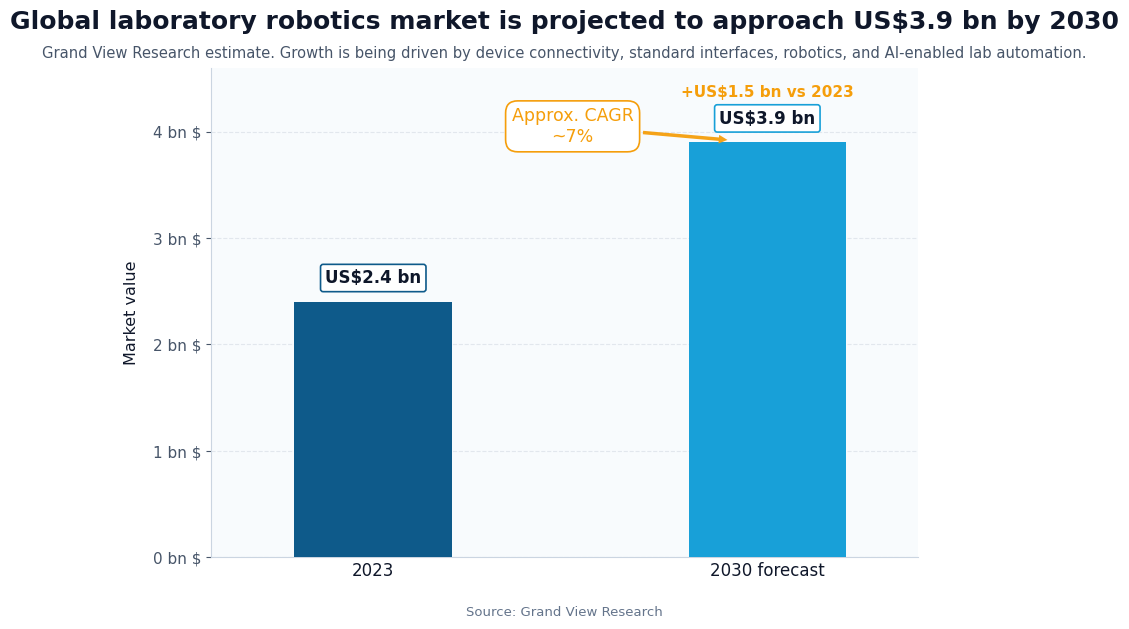

In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

years = ["2023", "2030 forecast"]
market_size = [2.4, 3.9]
bar_positions = [0, 1.7]

bar_colors = ["#0E5A8A", "#18A0D8"]
accent_color = "#F59E0B"
text_color = "#0F172A"
muted_color = "#475569"
background_color = "#F8FBFD"

cagr_percent = 7
market_growth = market_size[1] - market_size[0]

fig, ax = plt.subplots(figsize=(10.4, 6.4), facecolor="white")
ax.set_facecolor(background_color)

bars = ax.bar(
    bar_positions,
    market_size,
    width=0.68,
    color=bar_colors,
    edgecolor="none",
    zorder=3,
)

ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.22, color="#94A3B8")
ax.xaxis.grid(False)

# Place value labels above the bars so they remain readable on slides.
for bar, value, color in zip(bars, market_size, bar_colors):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.14,
        f"US${value:.1f} bn",
        ha="center",
        va="bottom",
        fontsize=12,
        color=text_color,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.28,rounding_size=0.16",
            facecolor="white",
            edgecolor=color,
            linewidth=1.2,
        ),
        zorder=6,
    )

ax.annotate(
    "Approx. CAGR\n~7%",
    xy=(bar_positions[1] - 0.16, market_size[1] + 0.02),
    xytext=(0.86, 4.05),
    ha="center",
    va="center",
    fontsize=12.5,
    color=accent_color,
    bbox=dict(
        boxstyle="round,pad=0.35,rounding_size=0.7",
        facecolor="white",
        edgecolor=accent_color,
        linewidth=1.2,
    ),
    arrowprops=dict(arrowstyle="simple", fc=accent_color, ec=accent_color, lw=0, alpha=0.95),
    zorder=5,
)

ax.text(
    0.5,
    1.08,
    "Global laboratory robotics market is projected to approach US$3.9 bn by 2030",
    transform=ax.transAxes,
    fontsize=18,
    fontweight="bold",
    color=text_color,
    ha="center",
)

ax.text(
    0.5,
    1.02,
    "Grand View Research estimate. Growth is being driven by device connectivity, standard interfaces, robotics, and AI-enabled lab automation.",
    transform=ax.transAxes,
    fontsize=10.6,
    color=muted_color,
    ha="center",
)

ax.text(
    bar_positions[1],
    market_size[1] + 0.4,
    f"+US${market_growth:.1f} bn vs 2023",
    ha="center",
    va="bottom",
    fontsize=11,
    color=accent_color,
    fontweight="bold",
    zorder=6,
)

ax.set_xticks(bar_positions, years)
ax.tick_params(axis="x", labelsize=12, colors=text_color, length=0)
ax.tick_params(axis="y", labelsize=11, colors=muted_color)
ax.set_ylim(0, 4.6)
ax.set_xlim(-0.7, 2.35)
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{int(value)} bn $" if value.is_integer() else f"{value:.1f} bn $"))
ax.set_ylabel("Market value", fontsize=11.5, color=text_color, labelpad=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#CBD5E1")
ax.spines["bottom"].set_color("#CBD5E1")

ax.text(
    0.5,
    -0.12,
    "Source: Grand View Research",
    transform=ax.transAxes,
    fontsize=9.5,
    color="#64748B",
    ha="center",
)

plt.tight_layout()
plt.show()